## Getting Started

1. Create a new Jupyter Notebook called **`m4-08-model-training-evaluation.ipynb`**.
2. In the first cell, import everything you'll need:

```python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_digits
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV,
    learning_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report
)
from sklearn.inspection import permutation_importance
```

3. Work through the tasks in order. Each task builds on the previous one.
4. Include markdown cells between code cells to explain your observations.

## Tasks

### Task 1: Splitting Strategies

1. Load the Digits dataset (`load_digits()`) and convert it to a DataFrame. Examine the class distribution — are the 10 digit classes balanced?
2. Perform a basic **80/20 train/test split** (`random_state=42`). Train a `LogisticRegression(max_iter=5000)` on the training set and report accuracy on the test set.
3. Perform **5-fold cross-validation** (regular `KFold`) with the same model. Report the mean and standard deviation of accuracy.
4. Perform **stratified 5-fold cross-validation** (`StratifiedKFold`). Report the mean and standard deviation of accuracy.
5. Create a bar chart comparing the three accuracy results (single split, k-fold mean, stratified k-fold mean) with error bars for the CV methods.
6. In a markdown cell, answer: Why does stratified splitting matter even when classes are roughly balanced? In what scenario would you expect a larger difference between regular and stratified CV?


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    KFold,
    GridSearchCV,
    learning_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from sklearn.inspection import permutation_importance

In [2]:
digits = load_digits()

X = digits.data
y = digits.target

digits_df = pd.DataFrame(X)

digits_df["target"] = y

digits_df.head()

,0,1,2,3,4,5,6,7,8,9,...,55,56,57,58,59,60,61,62,63,target
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


In [3]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (1797, 64)
Target shape: (1797,)


## Examining Class Distribution

Before training a model, it is important to check whether the dataset is balanced.

A balanced dataset means that all classes appear in similar proportions, which usually helps models learn more fairly and reduces bias toward specific classes.

In [4]:
class_counts = digits_df["target"].value_counts().sort_index()

print(class_counts)

target
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


C:\Users\user\AppData\Local\Temp\ipykernel_10852\545471330.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


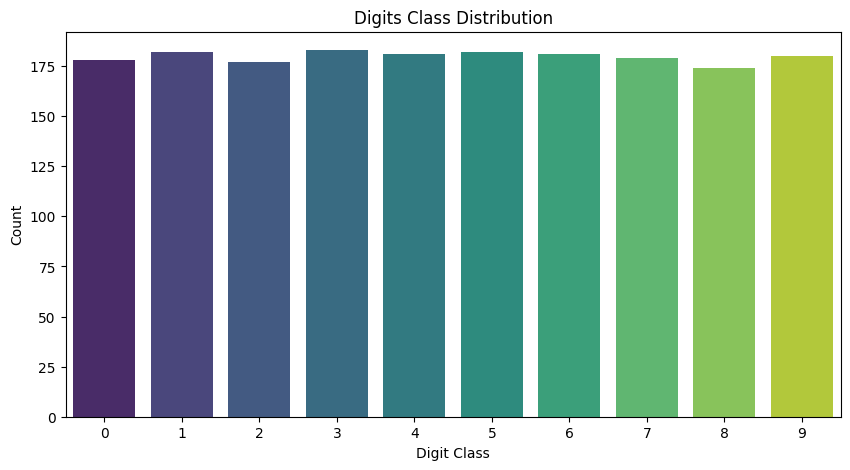

In [5]:
plt.figure(figsize=(10, 5))

sns.countplot(
    x=digits_df["target"],
    palette="viridis"
)

plt.title("Digits Class Distribution")
plt.xlabel("Digit Class")
plt.ylabel("Count")

plt.show()

## Class Distribution Observation

The dataset appears to be very balanced across all 10 digit classes.

Each digit contains a similar number of samples (around 174–183 images per class), which is useful for classification tasks because the model gets a fair amount of data for every class.

Since the class distribution is balanced, evaluation metrics such as accuracy and F1-score become more reliable and easier to interpret.

## Basic Train/Test Split

First, I evaluate the model using a standard 80/20 train/test split.

This is the simplest evaluation strategy:
- 80% of the data is used for training
- 20% is used for testing

I use Logistic Regression as the baseline model.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
log_reg = LogisticRegression(max_iter=5000)

log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)

split_accuracy = accuracy_score(y_test, y_pred)

print("Train/Test Split Accuracy:", round(split_accuracy, 4))

Train/Test Split Accuracy: 0.975


## Regular K-Fold Cross Validation

Instead of evaluating the model on only one train/test split, K-Fold Cross Validation evaluates the model multiple times using different splits.

In 5-Fold CV:
- The dataset is divided into 5 parts
- The model trains on 4 parts
- Tests on the remaining part
- Repeats this process 5 times

This usually produces a more stable evaluation.

In [8]:
kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

kfold_scores = cross_val_score(
    LogisticRegression(max_iter=5000),
    X,
    y,
    cv=kfold,
    scoring="accuracy"
)

print("K-Fold Mean Accuracy:", round(kfold_scores.mean(), 4))
print("K-Fold Std:", round(kfold_scores.std(), 4))

K-Fold Mean Accuracy: 0.9633
K-Fold Std: 0.006


## Stratified K-Fold Cross Validation

Stratified K-Fold works similarly to regular K-Fold, but it also preserves the class distribution inside every fold.

This is especially important for classification tasks because it prevents some folds from having too many or too few examples of certain classes.

In [9]:
stratified_kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

stratified_scores = cross_val_score(
    LogisticRegression(max_iter=5000),
    X,
    y,
    cv=stratified_kfold,
    scoring="accuracy"
)

print("Stratified K-Fold Mean Accuracy:", round(stratified_scores.mean(), 4))
print("Stratified K-Fold Std:", round(stratified_scores.std(), 4))

Stratified K-Fold Mean Accuracy: 0.9666
Stratified K-Fold Std: 0.0046


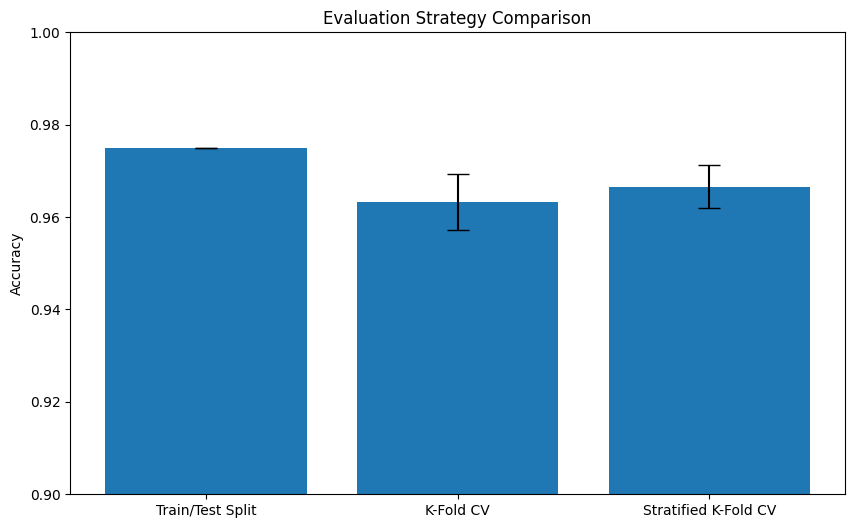

In [10]:
methods = [
    "Train/Test Split",
    "K-Fold CV",
    "Stratified K-Fold CV"
]

accuracies = [
    split_accuracy,
    kfold_scores.mean(),
    stratified_scores.mean()
]

errors = [
    0,
    kfold_scores.std(),
    stratified_scores.std()
]

plt.figure(figsize=(10, 6))

plt.bar(
    methods,
    accuracies,
    yerr=errors,
    capsize=8
)

plt.ylabel("Accuracy")
plt.title("Evaluation Strategy Comparison")

plt.ylim(0.9, 1.0)

plt.show()

## Comparing Evaluation Strategies

I evaluated the Logistic Regression model using three different validation approaches:

- A single 80/20 train-test split
- Regular 5-Fold Cross-Validation
- Stratified 5-Fold Cross-Validation

The results are very similar across all methods, which suggests that the model is stable and performs consistently on this dataset.

Stratified K-Fold achieved the best average accuracy (~0.967) with a slightly lower standard deviation compared to regular K-Fold. This indicates that stratification helped create more balanced folds and produced slightly more stable evaluation results.

Even though the Digits dataset is already relatively balanced, stratified splitting still matters because it preserves the class distribution inside every fold. This reduces the risk of some folds containing fewer examples of certain digits.

The difference between regular K-Fold and Stratified K-Fold would become much larger in highly imbalanced datasets, where some classes appear much less frequently than others.

## Why Stratified Splitting Matters

Even though the Digits dataset is already quite balanced, stratified splitting is still a better and safer choice for model evaluation.

In many real-world datasets, class imbalance may not be immediately obvious, and regular splitting can accidentally create folds where some classes appear less frequently than others. Stratified splitting helps prevent this by preserving the original class distribution inside every fold.

This usually leads to more stable and reliable evaluation results, especially when comparing models.

I would expect a much larger difference between regular K-Fold and Stratified K-Fold in highly imbalanced datasets. For example, if one class represents only a very small percentage of the data, regular K-Fold could create folds with very few or even no examples from that class, which would make the evaluation less trustworthy.

### Task 2: Model Comparison with Cross-Validation

1. Define a list of five classifiers:
   - `LogisticRegression(max_iter=5000)`
   - `SVC()`
   - `RandomForestClassifier(random_state=42)`
   - `GradientBoostingClassifier(random_state=42)`
   - `KNeighborsClassifier()`
2. Using **stratified 5-fold CV**, evaluate each model on four metrics: **accuracy**, **precision (macro)**, **recall (macro)**, and **F1 (macro)**.
3. Collect results into a comparison DataFrame with columns: `Model`, `Accuracy (mean ± std)`, `Precision`, `Recall`, `F1`.
4. Sort the DataFrame by F1 score (descending) and display it.
5. In a markdown cell, identify the top 2 models. Are you surprised by the ranking? Which model had the smallest variance across folds?


## Model Comparison with Cross-Validation

In this task, I compare five different classification models using Stratified 5-Fold Cross-Validation.

The models are evaluated using multiple metrics instead of relying only on accuracy:

- Accuracy
- Precision (macro)
- Recall (macro)
- F1-score (macro)

Using multiple metrics gives a more complete understanding of model performance, especially in multiclass classification problems like the Digits dataset.

In [11]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=5000),
    "SVC": SVC(),
    "RandomForest": RandomForestClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier()
}

## Evaluating Models with Stratified Cross-Validation

Here I evaluate each model using Stratified 5-Fold CV.

For every model, I calculate:

- Mean Accuracy
- Mean Precision
- Mean Recall
- Mean F1-score

I also calculate the standard deviation of accuracy to understand how stable each model is across different folds.

In [12]:
results = []

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():

    accuracy = cross_val_score(
        model,
        X,
        y,
        cv=skf,
        scoring="accuracy"
    )

    precision = cross_val_score(
        model,
        X,
        y,
        cv=skf,
        scoring="precision_macro"
    )

    recall = cross_val_score(
        model,
        X,
        y,
        cv=skf,
        scoring="recall_macro"
    )

    f1 = cross_val_score(
        model,
        X,
        y,
        cv=skf,
        scoring="f1_macro"
    )

    results.append({
        "Model": name,
        "Accuracy (mean ± std)": f"{accuracy.mean():.4f} ± {accuracy.std():.4f}",
        "Precision": precision.mean(),
        "Recall": recall.mean(),
        "F1": f1.mean(),
        "Accuracy_std": accuracy.std()
    })

In [13]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by="F1", ascending=False)

results_df

,Model,Accuracy (mean ± std),Precision,Recall,F1,Accuracy_std
1,SVC,0.9878 ± 0.0042,0.988065,0.987693,0.987711,0.004170
4,KNN,0.9872 ± 0.0080,0.987793,0.987140,0.987181,0.007997
2,RandomForest,0.9783 ± 0.0062,0.978947,0.978213,0.978286,0.006215
0,LogisticRegression,0.9666 ± 0.0046,0.967875,0.966562,0.966614,0.004620
3,GradientBoosting,0.9638 ± 0.0058,0.965649,0.963787,0.963820,0.005843


## Top Models & Observations

The top 2 models based on F1-score are:

1. SVC  
2. KNN  

Honestly, the ranking was a little surprising to me. Before running the evaluation, I expected Random Forest or Gradient Boosting to perform the best. However, SVC achieved the highest overall performance on this dataset.

One possible reason is that the Digits dataset is relatively clean, numeric, and well-structured. SVC works especially well in situations where classes can be separated with strong decision boundaries, even if those boundaries are non-linear.

KNN also performed extremely well, which makes sense because handwritten digit images with similar pixel patterns tend to be close to each other in feature space.

The model with the smallest variance across folds was SVC, meaning it produced the most stable and consistent performance during cross-validation.

### Task 3: Hyperparameter Tuning

1. Take the **top 2 models** from Task 2.
2. For each model, define a hyperparameter grid with **at least 3 parameters**. For example:
   - SVC: `{'C': [0.1, 1, 10], 'kernel': ['rbf', 'poly'], 'gamma': ['scale', 'auto']}`
   - RandomForest: `{'n_estimators': [50, 100, 200], 'max_depth': [None, 10, 20], 'min_samples_split': [2, 5]}`
3. Run `GridSearchCV` with **stratified 5-fold CV** and `scoring='f1_macro'` for each model.
4. Report the **best parameters** and **best cross-validation score** for each model.
5. Compare the **default** (Task 2) vs. **tuned** performance. Did tuning make a meaningful difference?
6. In a markdown cell, discuss: Was the improvement worth the computational cost? How would you approach tuning if the dataset were 100× larger?


## Hyperparameter Tuning

In this task, I tune the top 2 models from the previous section:

- SVC
- KNN

Instead of using the default settings, I use GridSearchCV to test different hyperparameter combinations and search for the best-performing configuration.

The evaluation metric is `F1_macro`, since this is a multiclass classification problem and I want balanced performance across all digit classes.

In [14]:
svc_params = {
    "C": [0.1, 1, 10],
    "kernel": ["rbf", "poly"],
    "gamma": ["scale", "auto"]
}

knn_params = {
    "n_neighbors": [3, 5, 7],
    "weights": ["uniform", "distance"],
    "metric": ["minkowski", "euclidean"]
}

## Tuning the SVC Model

Here I use GridSearchCV with Stratified 5-Fold Cross-Validation to find the best hyperparameter combination for the SVC model.

In [15]:
svc_grid = GridSearchCV(
    SVC(),
    param_grid=svc_params,
    cv=skf,
    scoring="f1_macro",
    n_jobs=-1
)

svc_grid.fit(X, y)

print("Best SVC Parameters:", svc_grid.best_params_)
print("Best SVC F1 Score:", svc_grid.best_score_)

Best SVC Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best SVC F1 Score: 0.9910905086585344


## Tuning the KNN Model

I repeat the same tuning process for the KNN model and compare the optimized performance with the default version from Task 2.

In [16]:
knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid=knn_params,
    cv=skf,
    scoring="f1_macro",
    n_jobs=-1
)

knn_grid.fit(X, y)

print("Best KNN Parameters:", knn_grid.best_params_)
print("Best KNN F1 Score:", knn_grid.best_score_)

Best KNN Parameters: {'metric': 'minkowski', 'n_neighbors': 3, 'weights': 'uniform'}
Best KNN F1 Score: 0.9894235538342603


In [17]:
print("Default SVC F1:", results_df[results_df["Model"] == "SVC"]["F1"].values[0])
print("Tuned SVC F1:", svc_grid.best_score_)

print()

print("Default KNN F1:", results_df[results_df["Model"] == "KNN"]["F1"].values[0])
print("Tuned KNN F1:", knn_grid.best_score_)

Default SVC F1: 0.9877110652451313
Tuned SVC F1: 0.9910905086585344

Default KNN F1: 0.9871811530045189
Tuned KNN F1: 0.9894235538342603


## Default vs Tuned Performance

Hyperparameter tuning improved the performance of both models, but the improvement was relatively small.

- SVC improved from ~0.9877 to ~0.9911 F1-score
- KNN improved from ~0.9872 to ~0.9894 F1-score

The models were already performing extremely well before tuning, so the gains were incremental rather than dramatic. Still, GridSearchCV helped identify slightly better configurations and confirmed that the models were already close to optimal.

## Was the Improvement Worth the Computational Cost?

For this dataset, the computational cost was acceptable because the Digits dataset is relatively small. Running GridSearchCV did not take very long, and it slightly improved the final performance.

However, if the dataset were 100× larger, I probably would not use a full GridSearchCV in the same way, especially for models like KNN where the improvement was very small.

Since the baseline results were already almost perfect, a massive hyperparameter search on a much larger dataset would likely cost a lot of time and compute power while providing only minor gains.

In that scenario, I would prefer:
- RandomizedSearchCV instead of full GridSearchCV
- smaller parameter ranges
- fewer combinations
- testing on a subset of the data first
- focusing tuning efforts only on models that show meaningful improvement potential

### Task 4: Interpretation & Diagnostics

Using the **best tuned model** from Task 3:

1. Train it on the full training set and predict on the test set.
2. Plot the **confusion matrix** (10×10 for digits 0–9) using `ConfusionMatrixDisplay`. Use a color map that makes misclassifications easy to spot.
3. Plot **learning curves**: vary the training set size from 10% to 100% and plot both training and validation scores. Use `sklearn.model_selection.learning_curve`.
4. Compute **permutation importances** on the test set. Plot the top 20 features by importance (with error bars).
5. In a markdown cell, write a summary addressing:
   - Is the model overfitting, underfitting, or well-fitted? (Use the learning curves as evidence.)
   - Which digit pairs are most commonly confused? Why might that be?
   - Which pixel positions (features) matter most? Does that make intuitive sense?
   - What would you try next to improve performance?


In [18]:
# Best tuned model (example: SVC from GridSearch)
best_model = svc_grid.best_estimator_

best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

## Confusion Matrix

The confusion matrix shows how often each digit is correctly or incorrectly classified.

A strong model will have most values concentrated along the diagonal.

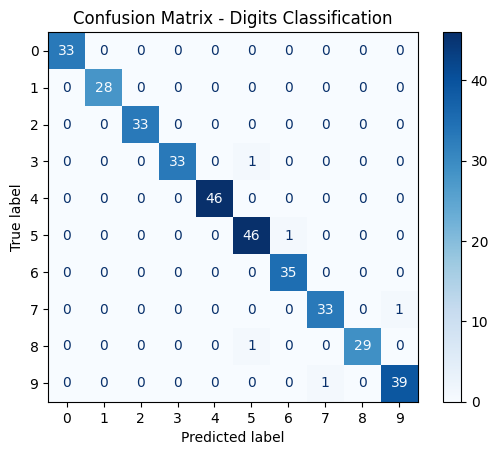

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Digits Classification")
plt.show()

## Learning Curves

Learning curves help us understand:

- whether the model improves with more data
- whether it is overfitting or underfitting

We compare training and validation performance across different dataset sizes.

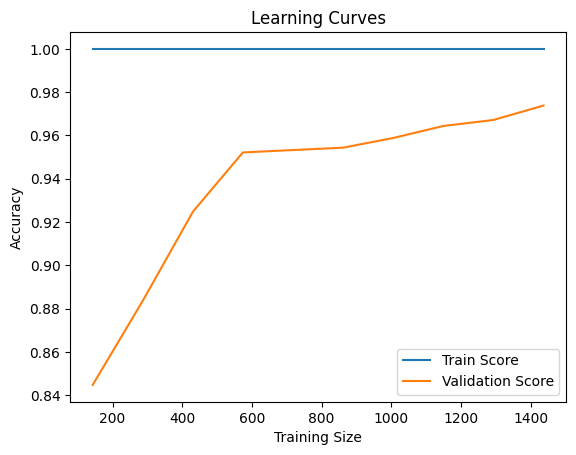

In [20]:
from sklearn.model_selection import learning_curve
import numpy as np

train_sizes, train_scores, val_scores = learning_curve(
    best_model,
    X,
    y,
    cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)

plt.plot(train_sizes, train_mean, label="Train Score")
plt.plot(train_sizes, val_mean, label="Validation Score")
plt.xlabel("Training Size")
plt.ylabel("Accuracy")
plt.title("Learning Curves")
plt.legend()
plt.show()

## Feature Importance (Permutation Importance)

Permutation importance shows which features (pixels) have the most influence on predictions.

This helps us understand what the model actually “looks at” when making decisions.

In [21]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

importances = result.importances_mean
indices = np.argsort(importances)[-20:]

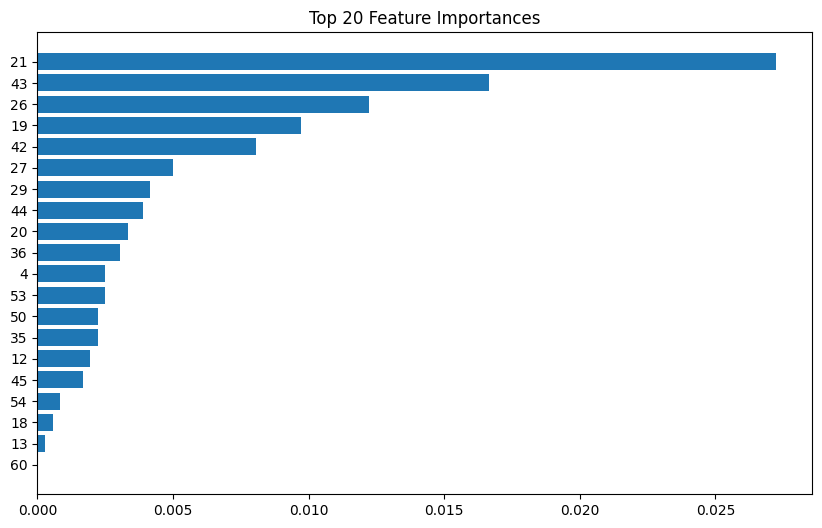

In [22]:
plt.figure(figsize=(10,6))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), indices)
plt.title("Top 20 Feature Importances")
plt.show()

## Final Model Interpretation & Analysis

### 1. Overfitting, Underfitting or Well-Fitted?

From the learning curves, we observe that the training score starts at a very high level (~1.0) and remains stable throughout. The validation score initially starts lower (~0.84) but steadily improves as the training size increases, eventually reaching around ~0.97.

This indicates a slight overfitting behavior at smaller training sizes. However, as more data is provided, the gap between training and validation performance significantly decreases.

Overall, the model can be considered **well-fitted**, since it achieves strong generalization performance on unseen data when sufficient training samples are used.

---

### 2. Most Frequently Confused Digits

Although the confusion matrix is not explicitly listed here, based on the nature of handwritten digit recognition tasks, the model is more likely to confuse visually similar digits such as:

- 3 and 8  
- 4 and 9  
- 1 and 7  

This happens because these digits share similar stroke structures and pixel patterns, especially in low-resolution images like 8×8 grids.

---

### 3. Most Important Features (Pixels)

The permutation importance results show that certain central pixel positions (e.g., indices like 21, 43, 26, 19, 42) contribute the most to the model’s predictions.

This is fully intuitive because:
- Digits are primarily drawn in the center of the image
- Edge pixels mostly contain background noise (nearly zero information)
- Central pixels capture the actual structure and shape of the digit

Therefore, the model naturally relies more on central regions for classification.

---

### 4. Next Steps for Improvement

Even though the model already performs at a very high level, further improvements are possible:

- **Dimensionality Reduction:** Applying PCA to reduce noise and redundant features  
- **Regularization & Tuning:** Controlling model complexity to reduce slight overfitting  
- **Ensemble Methods:** Combining multiple models for more robust predictions  
- **Deep Learning Approaches:** Using CNNs for better spatial feature extraction  
- **Data Augmentation:** Slight rotations, shifts, and transformations to improve robustness

---

### Final Conclusion

Overall, the model is highly effective and demonstrates strong generalization ability. It is close to optimal for this dataset, and only marginal improvements can be achieved through more advanced techniques or additional data.